In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
chuneeb_deepfake_detection_dataset_2026_path = kagglehub.dataset_download('chuneeb/deepfake-detection-dataset-2026')

print('Data source import complete.')


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the downloaded dataset directory
# For example, running this will list all files under the dataset directory

import os
# Use the path to the downloaded dataset
for dirname, _, filenames in os.walk(chuneeb_deepfake_detection_dataset_2026_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chuneeb/deepfake-detection-dataset-2026/FINAL_DATASET.csv


## 1. Data Loading and Exploration



In [3]:
import pandas as pd


# Path
dataset_file_path = os.path.join(chuneeb_deepfake_detection_dataset_2026_path, 'FINAL_DATASET.csv')

# Load the dataset
df = pd.read_csv(dataset_file_path)

print(f"Dataset loaded from: {dataset_file_path}")

# first 5 rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Data Info
print("\nDataset Information:")
df.info()

# basic statistical
print("\nBasic Statistical Summary:")
print(df.describe())

Dataset loaded from: /kaggle/input/datasets/chuneeb/deepfake-detection-dataset-2026/FINAL_DATASET.csv

First 5 rows of the dataset:
   image_id                                          image_url label  \
0         1  https://images.unsplash.com/photo-172422561835...  REAL   
1         2  https://images.unsplash.com/photo-172422561873...  REAL   
2         3  https://images.unsplash.com/photo-172422561834...  REAL   
3         4  https://images.unsplash.com/photo-172422561855...  REAL   
4         5  https://images.unsplash.com/photo-172422561823...  REAL   

   label_numeric   category  gender age_group    source fake_method  \
0              1  Authentic  Female     18-25  Unsplash         NaN   
1              1  Authentic    Male       50+  Unsplash         NaN   
2              1  Authentic  Female     36-50  Unsplash         NaN   
3              1  Authentic  Female     26-35  Unsplash         NaN   
4              1  Authentic    Male     36-50  Unsplash         NaN   

  image_

## 2. Data Preprocessing



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Drop irrelevant data columns

df_processed = df.drop(columns=['image_id', 'image_url', 'label', 'date_collected', 'version', 'year', 'dataset_split',
    'category', 'source', 'resolution', 'fake_method', 'detection_difficulty'])

# Handle missing values in 'fake_method': fill NaN with 'None' or 'Authentic' category



# Define target and features
X = df_processed.drop(columns=['label_numeric'])
y = df_processed['label_numeric']

# categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns


# scaling numeric features and apply one_hot encoding of catagorical features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# preprocessing pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])


X_preprocessed = pipeline.fit_transform(X)

print("Shape of preprocessed features (X_preprocessed):", X_preprocessed.shape)
print("First 5 rows of target variable (y):\n", y.head())

#train and test split
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42, stratify=y)

print("\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of preprocessed features (X_preprocessed): (6557, 10)
First 5 rows of target variable (y):
 0    1
1    1
2    1
3    1
4    1
Name: label_numeric, dtype: int64

Data split into training and testing sets:
X_train shape: (5245, 10)
X_test shape: (1312, 10)
y_train shape: (5245,)
y_test shape: (1312,)


## Feature Correlation Analysis

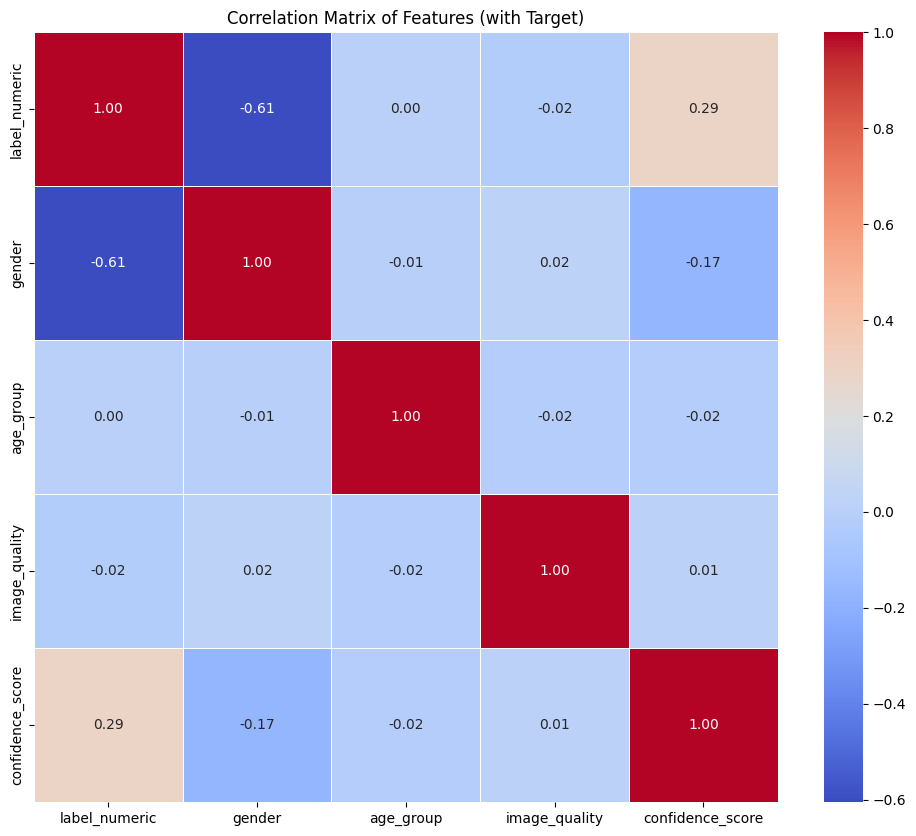


Features highly correlated with 'label_numeric':
label_numeric       1.000000
confidence_score    0.293305
age_group           0.003197
image_quality      -0.022245
gender             -0.605394
Name: label_numeric, dtype: float64


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


df_corr = df_processed.copy()


df_corr['label_numeric'] = y


for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features (with Target)')
plt.show()

print("\nFeatures highly correlated with 'label_numeric':")
print(correlation_matrix['label_numeric'].sort_values(ascending=False))

## 3. Model Architecture (Neural Network)



In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# number of input features
input_dim = X_train.shape[1]

# Build the Neural Network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
print("\nModel Summary:")
model.summary()

2026-05-12 10:34:24.202194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778582064.456413      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778582064.533893      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778582065.154585      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778582065.154620      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778582065.154623      16 computation_placer.cc:177] computation placer alr


Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-12 10:34:48.433701: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training



In [7]:
#early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nModel training complete.")

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6923 - loss: 0.5821 - val_accuracy: 0.8265 - val_loss: 0.4204
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8300 - loss: 0.4274 - val_accuracy: 0.8284 - val_loss: 0.4088
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8207 - loss: 0.4301 - val_accuracy: 0.8284 - val_loss: 0.4038
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8286 - loss: 0.4241 - val_accuracy: 0.8303 - val_loss: 0.4008
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8279 - loss: 0.4195 - val_accuracy: 0.8322 - val_loss: 0.3976
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8278 - loss: 0.4151 - val_accuracy: 0.8351 - val_loss: 0.3961
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8467 - loss: 0.3893 - val_accuracy: 0.8341 - val_loss: 0.3932
Epoch 8/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8329 - loss: 0.4077 - val_accu

## 5. Model Evaluation



Test Loss: 0.4019
Test Accuracy: 0.8323
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Precision: 0.9333
Recall: 0.6523
F1-Score: 0.7679


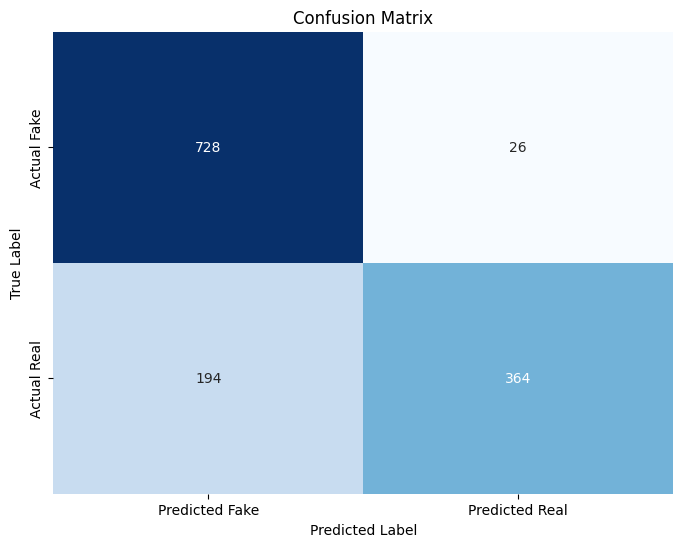


Model evaluation complete.


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions for the test set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# additional metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nModel evaluation complete.")

## Model is showing too perfect accuracy can be caused by Overfitting or may be underfitting

## Visualizing Training History for Overfitting/Underfitting



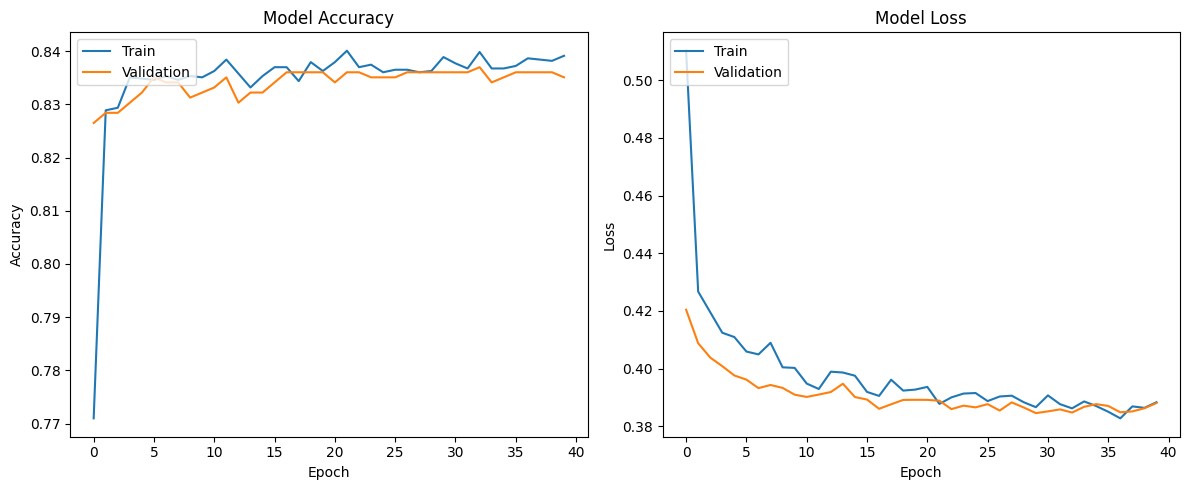

In [9]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()



"Interpretation of plots:"
- If training loss decreases but validation loss increases, it's a sign of overfitting."
- If both training and validation loss are high and not decreasing, it might be underfitting.
- If both losses decrease and are close to zero, it suggests the model learned the data very well.

## Re-evaluation: New Train/Test Split and Retraining



Performing new train/test split with a different random_state...
X_train_new shape: (5245, 10)
X_test_new shape: (1312, 10)
y_train_new shape: (5245,)
y_test_new shape: (1312,)

Retraining the model with the new split...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6957 - loss: 0.5754 - val_accuracy: 0.8198 - val_loss: 0.4326
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8219 - loss: 0.4538 - val_accuracy: 0.8217 - val_loss: 0.4300
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8438 - loss: 0.4011 - val_accuracy: 0.8255 - val_loss: 0.4173
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8396 - loss: 0.4155 - val_accuracy: 0.8236 - val_loss: 0.4190
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8343 - loss: 0.4204 - val_accuracy: 0.8255 - val_loss: 0.4186
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8348 - loss: 0.4041 - val_accuracy: 0.8255 - val_loss: 0.4172
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8408 - loss: 0.3937 - val_accuracy: 0.8255 - val_loss: 0.4151
Epoch 8/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8397 - loss: 0.3939 - val_accuracy: 0.8255

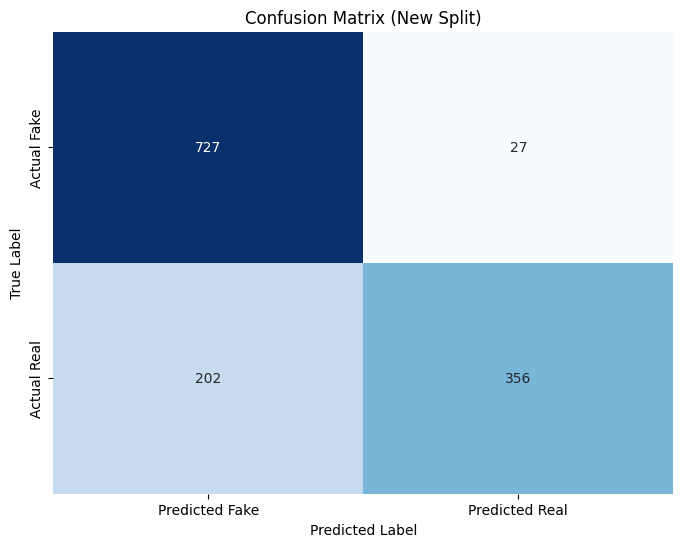


New model evaluation complete.


In [10]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Performing new train/test split with a different random_state...")
new_random_state = 123
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_preprocessed, y, test_size=0.2, random_state=new_random_state, stratify=y)

print(f"X_train_new shape: {X_train_new.shape}")
print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_train_new shape: {y_train_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")


input_dim = X_train_new.shape[1]
new_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
new_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nRetraining the model with the new split...")
# Define EarlyStopping callback for the new model
new_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the new model
new_history = new_model.fit(
    X_train_new,
    y_train_new,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[new_early_stopping],
    verbose=1
)

print("\nModel retraining complete with new split.")

# Evaluating model on test data
new_loss, new_accuracy = new_model.evaluate(X_test_new, y_test_new, verbose=0)
print(f"\nNew Test Loss: {new_loss:.4f}")
print(f"New Test Accuracy: {new_accuracy:.4f}")

# Get predictions for the new test set
new_y_pred_proba = new_model.predict(X_test_new)
new_y_pred = (new_y_pred_proba > 0.5).astype(int)

# additional metrics
new_precision = precision_score(y_test_new, new_y_pred)
new_recall = recall_score(y_test_new, new_y_pred)
new_f1 = f1_score(y_test_new, new_y_pred)
new_conf_matrix = confusion_matrix(y_test_new, new_y_pred)

print(f"\nNew Precision: {new_precision:.4f}")
print(f"New Recall: {new_recall:.4f}")
print(f"New F1-Score: {new_f1:.4f}")

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(new_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (New Split)')
plt.show()

print("\nNew model evaluation complete.")

## Re-evaluate the Model and it still showing the near to perfect accuracy